#SWIGGY SALES ANALYSIS


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prompt_toolkit.contrib.telnet import TelnetServer



In [2]:
#load file
df=pd.read_excel("../Data/Raw/swiggy_data.xlsx")

print(df)

            State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2                    Kengeri  Recomm

In [3]:
#Review
df.head(5)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  str           
 1   City             197430 non-null  str           
 2   Order Date       197430 non-null  datetime64[us]
 3   Restaurant Name  197430 non-null  str           
 4   Location         197430 non-null  str           
 5   Category         197430 non-null  str           
 6   Dish Name        197430 non-null  str           
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 15.1 MB


In [4]:
print(df.columns)

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='str')


In [5]:
df.shape
df.describe()


,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [6]:
#handle any missing values
df.isnull().sum()


State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [7]:
#Fixes - Price (INR),rating,rating count
#These contain labels / names / categories, not numbers.
#- City ,state,category,resname,dishname

df['Rating']=df['Rating'].fillna(df['Rating'].mean())
df['City']=df['City'].fillna("unknown")

###remove duplicates


In [8]:
df=df.drop_duplicates()
df['City'].duplicated().sum()

np.int64(197375)

In [9]:
#Fix Data types

df = df.rename(columns={'Price (INR)': 'Price'})
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price', 'Rating', 'Rating Count'],
      dtype='str')

In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Price']=df['Price'].astype(float)

#Outlier



In [11]:
#remove extreme prices
df=df[df['Price']<df['Price'].quantile(0.99)]

#KPIS

In [12]:
df['Month']=df['Order Date'].dt.month
df['Day']=df['Order Date'].dt.day_name()
df['Quarter']=df['Order Date'].dt.quarter
df['week']=df['Order Date'].dt.isocalendar().week




In [35]:
Total_Sales=df['Price'].sum()
Avg_Rating=df['Rating'].mean()
Avg_order_value=df['Price'].mean()
Total_Orders=df.shape[0]
Ratings_Count=df['Rating'].count()
print(f"Total Sales is: {Total_Sales}")
print(f"Average Rating is: {Avg_Rating}")
print(f"Average Order Value is: {Avg_order_value}")
print(f"Total Orders is: {Total_Orders}")
print(f"Ratings Count is: {Ratings_Count}")

Total Sales is: 49780159.55
Average Rating is: 4.34073503599957
Average Order Value is: 254.73551471453644
Total Orders is: 195419
Ratings Count is: 195419


In [14]:
monthly_sales=df.groupby('month')['Price'].sum()
monthly_sales.plot(kind='line')
plt.title("Monthly sales trend")
plt.xlabel("month")
plt.ylabel("sales")
plt.show()

KeyError: 'month'

#

#Monthly sales trend


In [ ]:
df


In [ ]:
df.columns


In [ ]:
monthly_sales=df.groupby('Month')['Price'].sum()
monthly_sales.plot(kind='line')
plt.title("Monthly sales trend")

plt.xlabel("month")
plt.ylabel("sales")
plt.tight_layout()
plt.show()




In [ ]:
#Daily Sales Trend – Highlights order and revenue variations across days of the week.
daily_sales=df.groupby('Day')['Price'].sum()
order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales=daily_sales.reindex(order)
#plot
daily_sales.plot(kind='bar')
plt.title("Daily sales trend")
plt.xlabel("Day")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.show()



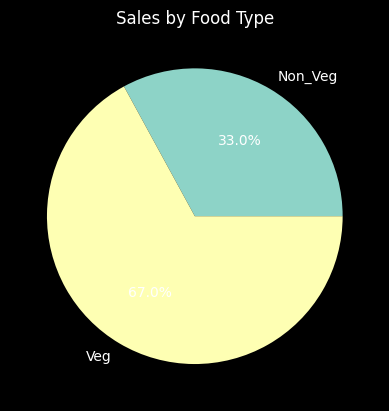

In [16]:
#Total sales by Foodtype(veg,Non veg)
#Define Non_veg Keywords
Non_veg_Keywords=["chicken","egg","fish","mutton","prawns","Biryani","Kebab"]
df['food_type']=df['Dish Name'].str.lower().apply(lambda x:"Non_Veg" if any(word in x for word in Non_veg_Keywords)else "Veg")
#Calucalte total food sales
food_sales=df.groupby("food_type")['Price'].sum()
food_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title('Sales by Food Type')

plt.show()

In [15]:
df.columns


Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price', 'Rating', 'Rating Count', 'Month',
       'Day', 'Quarter', 'week'],
      dtype='str')

In [17]:
df


,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price,Rating,Rating Count,Month,Day,Quarter,week,food_type
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,6,Sunday,2,26,Veg
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,4,Thursday,2,14,Veg
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,1,Wednesday,1,3,Veg
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,4,Thursday,2,16,Veg
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,3,Thursday,1,11,Veg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0,1,Saturday,1,4,Veg
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0,7,Wednesday,3,27,Veg
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0,3,Tuesday,1,13,Veg
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0,3,Wednesday,1,13,Veg


C:\Users\adity\AppData\Local\Temp\ipykernel_17000\4194089828.py:9: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adity\PycharmProjects\SwiggyProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


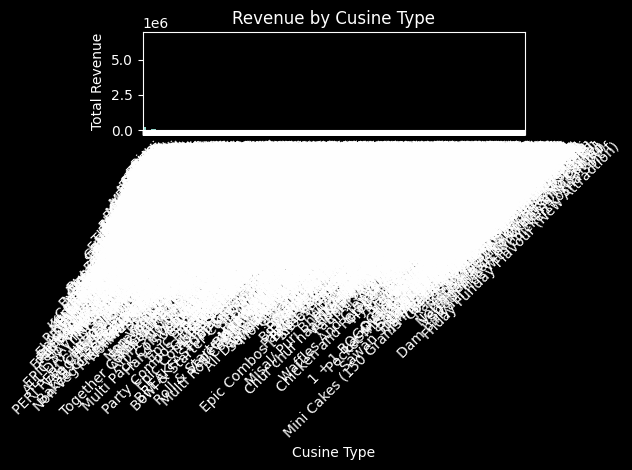

In [21]:
#Revenue by Cuisine Type
Cusine_Sales=df.groupby('Category')['Price'].sum().sort_values(ascending=False)

Cusine_Sales.plot(kind='bar')
plt.title("Revenue by Cusine Type")
plt.xlabel("Cusine Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



C:\Users\adity\AppData\Local\Temp\ipykernel_17000\651499954.py:4: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


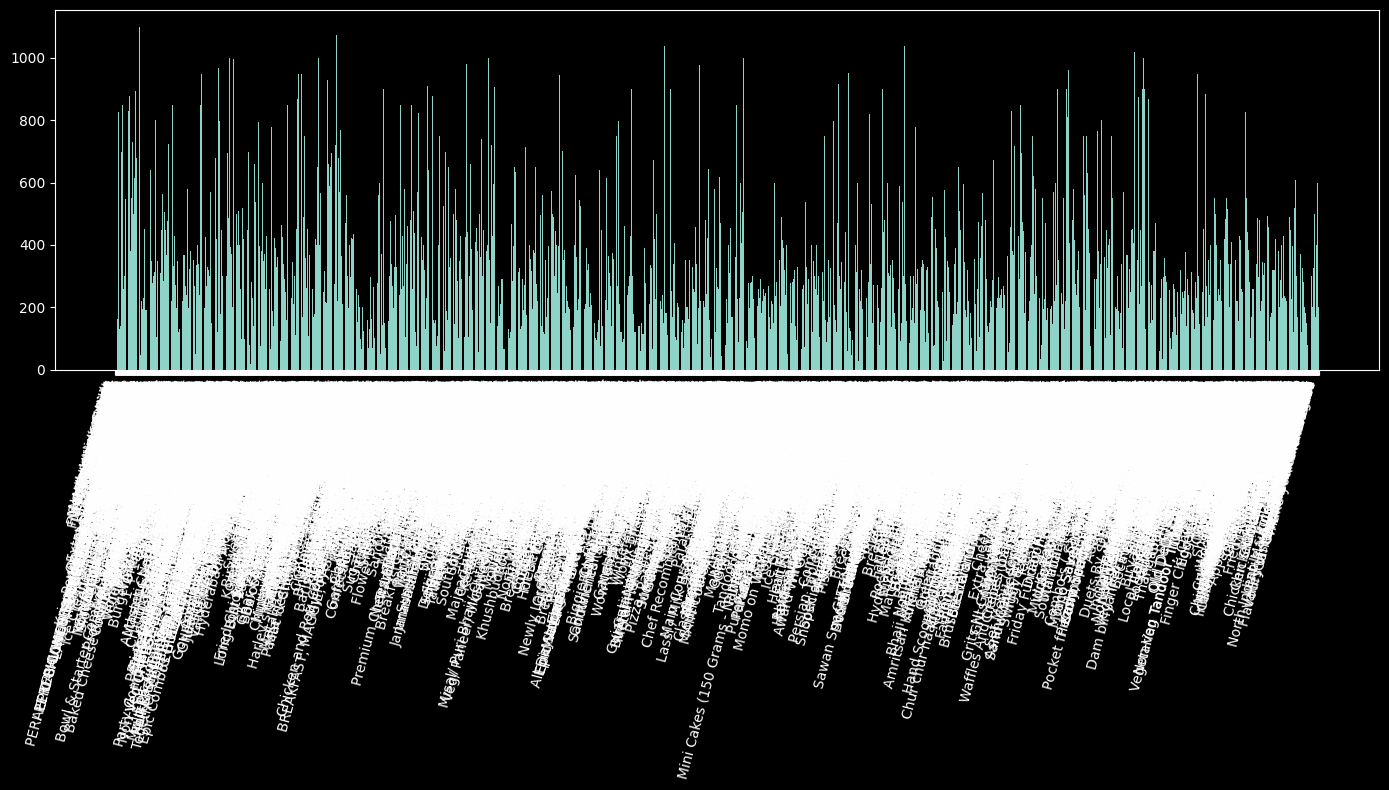

In [23]:
plt.figure(figsize=(14, 8))
plt.bar(df['Category'], df['Price'])
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()


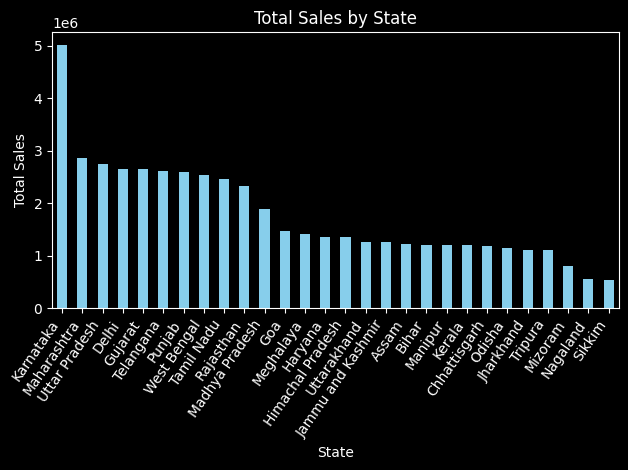

In [32]:
#Total Sales by State (Map Visualization) – Displays state-wise revenue distribution.

State_sales=df.groupby('State')['Price'].sum().sort_values(ascending=False)

State_sales.plot(kind='bar',color='Skyblue')
plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=55,ha='right')
plt.tight_layout()
plt.show()




In [38]:
#Quarterly Performance Summary – Combines Sales, Ratings, and Orders by Quarter.
#create a Quarter column

df['Quarter']=df['Order Date'].dt.to_period('Q')
#Group by Quarter
Quarterly_sales = df.groupby('Quarter').agg({
    Total_Sales: ('Price', 'sum'),
    Avg_Rating: ('Rating', 'mean'),
    Total_Orders: ('Order Date', 'count')
})
Quarterly_sales.plot(kind='bar')
plt.title("Quarterly sales trend")
plt.xlabel("Quarter")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()




KeyError: 'Label(s) [4.34073503599957, 195419.0, 49780159.55] do not exist'

In [34]:
df.columns


Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price', 'Rating', 'Rating Count', 'Month',
       'Day', 'Quarter', 'week', 'food_type'],
      dtype='str')

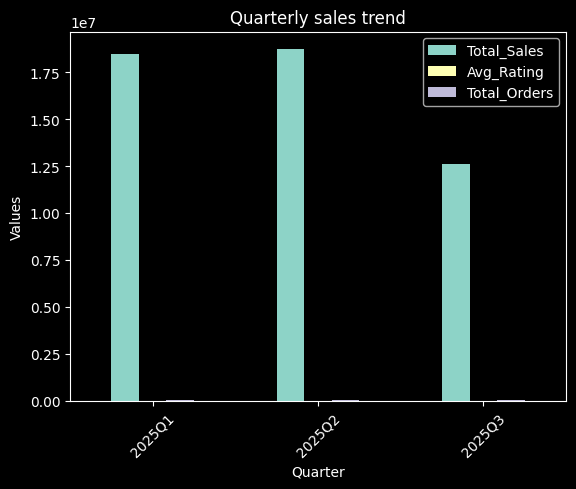

In [48]:
df.columns = df.columns.str.strip()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period('Q')

Quarterly_sales = df.groupby('Quarter').agg(
    Total_Sales=('Price', 'sum'),
    Avg_Rating=('Rating', 'mean'),
    Total_Orders=('Order Date', 'count')
)

Quarterly_sales.plot(kind='bar')
plt.title("Quarterly sales trend")
plt.xlabel("Quarter")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

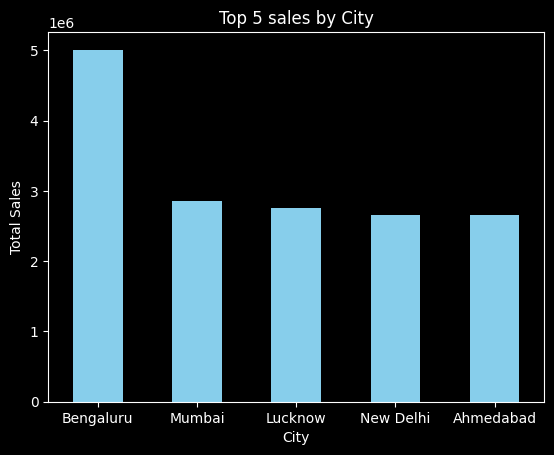

In [50]:
#Top 5 Cities by Sales – Identifies leading cities contributing the most revenue.
Top5_sales=df.groupby('City')['Price'].sum().nlargest(5)
Top5_sales.plot(kind='bar',title='Top 5 sales by City',color='skyblue')
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


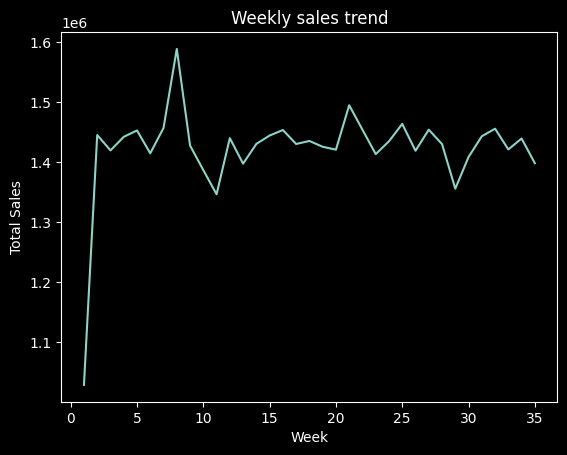

In [56]:
#Weekly Trend Analysis – Monitors weekly fluctuations in sales to identify consistency or peak periods.
df['week']=df['Order Date'].dt.isocalendar().week
#Group by week
Weekly_sales=df.groupby('week')['Price'].sum().sort_index()
Weekly_sales.plot(kind='line')
plt.title("Weekly sales trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.show()

